In [1]:
# ============================================================================
# ЛАБОРАТОРНАЯ РАБОТА №4 (ВАРИАНТ 2): УСЛОВНЫЙ ЭКСТРЕМУМ
# LABORATORY WORK #4 (VARIANT 2): CONSTRAINED EXTREMUM
# ============================================================================
# Функция 1.4
# f(x1, x2) = 3x1^2 + 4x1x2 + 5x2^2 → min
# g1(x) = 4 - x1 - x2 ≤ 0
# g2(x) = -x1 ≤ 0
# g3(x) = -x2 ≤ 0
# ============================================================================

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, diff, Matrix, solve, sqrt

# Настройка отображения
sp.init_printing()

print("=" * 60)
print("УСЛОВНЫЙ ЭКСТРЕМУМ ФУНКЦИИ 1.4")
print("CONSTRAINED EXTREMUM OF FUNCTION 1.4")
print("=" * 60)

# Определяем переменные
x1, x2 = symbols('x1 x2', real=True)

# Целевая функция
f = 3*x1**2 + 4*x1*x2 + 5*x2**2

# Ограничения
g1 = 4 - x1 - x2
g2 = -x1
g3 = -x2

print("\nЦелевая функция / Objective function:")
print(f"  f(x1, x2) = {f}")

print("\nОграничения / Constraints:")
print(f"  g1(x) = {g1} ≤ 0")
print(f"  g2(x) = {g2} ≤ 0")
print(f"  g3(x) = {g3} ≤ 0")

# Классическая функция Лагранжа
lambda1, lambda2, lambda3 = symbols('λ1 λ2 λ3', real=True)
L = f + lambda1 * g1 + lambda2 * g2 + lambda3 * g3

print(f"\nКлассическая функция Лагранжа / Classical Lagrangian:")
print(f"  L(x, λ) = {L}")

print("\n" + "=" * 60)

УСЛОВНЫЙ ЭКСТРЕМУМ ФУНКЦИИ 1.4
CONSTRAINED EXTREMUM OF FUNCTION 1.4

Целевая функция / Objective function:
  f(x1, x2) = 3*x1**2 + 4*x1*x2 + 5*x2**2

Ограничения / Constraints:
  g1(x) = -x1 - x2 + 4 ≤ 0
  g2(x) = -x1 ≤ 0
  g3(x) = -x2 ≤ 0

Классическая функция Лагранжа / Classical Lagrangian:
  L(x, λ) = 3*x1**2 + 4*x1*x2 - x1*λ2 + 5*x2**2 - x2*λ3 + λ1*(-x1 - x2 + 4)



In [3]:
# ============================================================================
# АНАЛИЗ БЕЗУСЛОВНОГО МИНИМУМА (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# UNCONSTRAINED MINIMUM ANALYSIS (CORRECTED VERSION)
# ============================================================================

print("=" * 60)
print("АНАЛИЗ БЕЗУСЛОВНОГО МИНИМУМА")
print("UNCONSTRAINED MINIMUM ANALYSIS")
print("=" * 60)

# Находим безусловный минимум
df_dx1 = diff(f, x1)
df_dx2 = diff(f, x2)

print(f"\nЧастные производные / Partial derivatives:")
print(f"  ∂f/∂x1 = {df_dx1}")
print(f"  ∂f/∂x2 = {df_dx2}")

# Решаем систему ∇f = 0
stationary_points = solve([df_dx1, df_dx2], (x1, x2), dict=True)
print(f"\nСтационарные точки (без ограничений) / Stationary points (unconstrained):")
for sol in stationary_points:
    x1_val = sol[x1]
    x2_val = sol[x2]
    print(f"  x1 = {x1_val}, x2 = {x2_val}")
    f_val = f.subs({x1: x1_val, x2: x2_val})
    print(f"  f(x1, x2) = {f_val}")

# Вычисляем матрицу Гессе
H = Matrix([[diff(f, x1, 2), diff(f, x1, x2)],
            [diff(f, x2, x1), diff(f, x2, 2)]])
print(f"\nМатрица Гессе / Hessian matrix:")
print(f"  H = {H}")

# Вычисляем определитель
det_H = H.det()
print(f"\nОпределитель Гессе / Hessian determinant: det(H) = {det_H}")

# Собственные значения
eigenvals = H.eigenvals()
print(f"\nСобственные значения / Eigenvalues: {eigenvals}")

# Определяем знак
if H[0,0] > 0 and det_H > 0:
    print("\n✓ Матрица Гессе положительно определена / Hessian matrix is positive definite")
    print("Вывод / Conclusion: Без ограничений функция имеет минимум в точке (0, 0)")
    print("Unconstrained: function has minimum at (0, 0)")
elif H[0,0] < 0 and det_H > 0:
    print("\n✓ Матрица Гессе отрицательно определена / Hessian matrix is negative definite")
    print("Вывод / Conclusion: Без ограничений функция имеет максимум в точке (0, 0)")
else:
    print("\n⚠ Стационарная точка является седловой / Stationary point is a saddle point")

print("\n✅ Анализ безусловного минимума завершен")

АНАЛИЗ БЕЗУСЛОВНОГО МИНИМУМА
UNCONSTRAINED MINIMUM ANALYSIS

Частные производные / Partial derivatives:
  ∂f/∂x1 = 6*x1 + 4*x2
  ∂f/∂x2 = 4*x1 + 10*x2

Стационарные точки (без ограничений) / Stationary points (unconstrained):
  x1 = 0, x2 = 0
  f(x1, x2) = 0

Матрица Гессе / Hessian matrix:
  H = Matrix([[6, 4], [4, 10]])

Определитель Гессе / Hessian determinant: det(H) = 44

Собственные значения / Eigenvalues: {8 - 2*sqrt(5): 1, 2*sqrt(5) + 8: 1}

✓ Матрица Гессе положительно определена / Hessian matrix is positive definite
Вывод / Conclusion: Без ограничений функция имеет минимум в точке (0, 0)
Unconstrained: function has minimum at (0, 0)

✅ Анализ безусловного минимума завершен


In [4]:
# ============================================================================
# АНАЛИЗ С ОГРАНИЧЕНИЯМИ (УСЛОВИЯ КАРУША-КУНА-ТАККЕРА)
# CONSTRAINED ANALYSIS (KKT CONDITIONS)
# ============================================================================

print("=" * 60)
print("УСЛОВИЯ КАРУША-КУНА-ТАККЕРА")
print("KARUSH-KUHN-TUCKER CONDITIONS")
print("=" * 60)

# Функция Лагранжа
L = f + lambda1 * g1 + lambda2 * g2 + lambda3 * g3
print(f"\nФункция Лагранжа / Lagrangian:")
print(f"  L = {L}")

# Условия стационарности
dL_dx1 = diff(L, x1)
dL_dx2 = diff(L, x2)

print(f"\nУсловия стационарности / Stationarity conditions:")
print(f"  ∂L/∂x1 = {dL_dx1} = 0")
print(f"  ∂L/∂x2 = {dL_dx2} = 0")

# Условия дополняющей нежесткости
print(f"\nУсловия дополняющей нежесткости / Complementary slackness:")
print(f"  λ1 * g1 = λ1 * ({g1}) = 0")
print(f"  λ2 * g2 = λ2 * ({g2}) = 0")
print(f"  λ3 * g3 = λ3 * ({g3}) = 0")

# Условия неотрицательности множителей (для минимума)
print(f"\nУсловия неотрицательности множителей / Non-negativity of multipliers (for min):")
print(f"  λ1 ≥ 0, λ2 ≥ 0, λ3 ≥ 0")

# Ограничения
print(f"\nОграничения / Constraints:")
print(f"  g1 = {g1} ≤ 0")
print(f"  g2 = {g2} ≤ 0")
print(f"  g3 = {g3} ≤ 0")

print("\n" + "=" * 60)
print("РЕШЕНИЕ СИСТЕМЫ KKT / SOLVING KKT SYSTEM")
print("=" * 60)

# Упрощаем выражения
print(f"\n∂L/∂x1 = {sp.simplify(dL_dx1)}")
print(f"∂L/∂x2 = {sp.simplify(dL_dx2)}")

print("\n✅ KKT условия сформулированы")

УСЛОВИЯ КАРУША-КУНА-ТАККЕРА
KARUSH-KUHN-TUCKER CONDITIONS

Функция Лагранжа / Lagrangian:
  L = 3*x1**2 + 4*x1*x2 - x1*λ2 + 5*x2**2 - x2*λ3 + λ1*(-x1 - x2 + 4)

Условия стационарности / Stationarity conditions:
  ∂L/∂x1 = 6*x1 + 4*x2 - λ1 - λ2 = 0
  ∂L/∂x2 = 4*x1 + 10*x2 - λ1 - λ3 = 0

Условия дополняющей нежесткости / Complementary slackness:
  λ1 * g1 = λ1 * (-x1 - x2 + 4) = 0
  λ2 * g2 = λ2 * (-x1) = 0
  λ3 * g3 = λ3 * (-x2) = 0

Условия неотрицательности множителей / Non-negativity of multipliers (for min):
  λ1 ≥ 0, λ2 ≥ 0, λ3 ≥ 0

Ограничения / Constraints:
  g1 = -x1 - x2 + 4 ≤ 0
  g2 = -x1 ≤ 0
  g3 = -x2 ≤ 0

РЕШЕНИЕ СИСТЕМЫ KKT / SOLVING KKT SYSTEM

∂L/∂x1 = 6*x1 + 4*x2 - λ1 - λ2
∂L/∂x2 = 4*x1 + 10*x2 - λ1 - λ3

✅ KKT условия сформулированы


In [6]:
# ============================================================================
# РАССМОТРЕНИЕ СЛУЧАЕВ (АКТИВНЫЕ/ПАССИВНЫЕ ОГРАНИЧЕНИЯ)
# CASE ANALYSIS (ACTIVE/INACTIVE CONSTRAINTS)
# ============================================================================

print("=" * 60)
print("АНАЛИЗ СЛУЧАЕВ / CASE ANALYSIS")
print("=" * 60)

# Создаем словарь для хранения результатов
candidates = []

def try_case(active_list, description, lam1_val=None, lam2_val=None, lam3_val=None):
    """Проверка конкретного случая"""
    print(f"\n--- {description} ---")
    
    # Формируем уравнения
    eqns = []
    eqns.append(6*x1 + 4*x2 - lambda1 - lambda2)
    eqns.append(4*x1 + 10*x2 - lambda1 - lambda3)
    
    unknowns = [x1, x2, lambda1, lambda2, lambda3]
    
    # Добавляем уравнения от активных ограничений
    if 'g1' in active_list:
        eqns.append(-x1 - x2 + 4)
    if 'g2' in active_list:
        eqns.append(-x1)
    if 'g3' in active_list:
        eqns.append(-x2)
    
    # Добавляем условия дополняющей нежесткости для неактивных
    if 'g1' not in active_list:
        eqns.append(lambda1)
    if 'g2' not in active_list:
        eqns.append(lambda2)
    if 'g3' not in active_list:
        eqns.append(lambda3)
    
    try:
        sol = sp.solve(eqns, unknowns, dict=True)
        for s in sol:
            # Проверяем неотрицательность множителей
            l1 = s.get(lambda1, 0)
            l2 = s.get(lambda2, 0)
            l3 = s.get(lambda3, 0)
            
            if l1 < -1e-10 or l2 < -1e-10 or l3 < -1e-10:
                print(f"  ✗ Отброшено: отрицательные множители / Rejected: negative multipliers")
                continue
            
            # Проверяем неактивные ограничения
            x1_val = s[x1]
            x2_val = s[x2]
            g1_val = (-x1 - x2 + 4).subs({x1: x1_val, x2: x2_val})
            if 'g1' not in active_list and g1_val > 1e-10:
                print(f"  ✗ Отброшено: g1 > 0 / Rejected: g1 > 0")
                continue
            
            print(f"  ✓ Найдена допустимая точка / Found feasible point:")
            print(f"    x1 = {x1_val.evalf()}, x2 = {x2_val.evalf()}")
            print(f"    λ1 = {l1.evalf()}, λ2 = {l2.evalf()}, λ3 = {l3.evalf()}")
            f_val = f.subs({x1: x1_val, x2: x2_val})
            print(f"    f(x) = {f_val.evalf()}")
            candidates.append((x1_val, x2_val, f_val, l1, l2, l3, description))
            return True
    except Exception as e:
        print(f"  Не удалось решить / Could not solve: {e}")
    
    print("  Нет допустимых решений / No feasible solutions")
    return False


print("\nРассмотрение различных комбинаций активных ограничений:")
print("Considering different combinations of active constraints:")

# Случай 1: Ни одно ограничение не активно (λ1=λ2=λ3=0)
print("\n1. Нет активных ограничений / No active constraints (λ1=λ2=λ3=0)")
try:
    sol = sp.solve([6*x1 + 4*x2, 4*x1 + 10*x2, lambda1, lambda2, lambda3], [x1, x2, lambda1, lambda2, lambda3], dict=True)
    for s in sol:
        x1_v = s[x1]
        x2_v = s[x2]
        # Проверяем ограничения
        if (-x1_v - x2_v + 4) <= 0 and (-x1_v) <= 0 and (-x2_v) <= 0:
            print(f"  ✓ Допустимая точка / Feasible point: ({x1_v}, {x2_v})")
            print(f"    f = {f.subs({x1: x1_v, x2: x2_v})}")
            candidates.append((x1_v, x2_v, f.subs({x1: x1_v, x2: x2_v}), 0, 0, 0, "no active"))
        else:
            print(f"  ✗ Точка ({x1_v}, {x2_v}) недопустима / infeasible")
except:
    print("  Нет решений / No solutions")

# Случай 2-8: Различные комбинации
try_case(['g1'], "2. Активно только g1 / Only g1 active")
try_case(['g2'], "3. Активно только g2 / Only g2 active")
try_case(['g3'], "4. Активно только g3 / Only g3 active")
try_case(['g1', 'g2'], "5. Активны g1 и g2 / g1 and g2 active")
try_case(['g1', 'g3'], "6. Активны g1 и g3 / g1 and g3 active")
try_case(['g2', 'g3'], "7. Активны g2 и g3 / g2 and g3 active (угол)")
try_case(['g1', 'g2', 'g3'], "8. Активны все / All active")

print("\n" + "=" * 60)
print("КАНДИДАТЫ НА ЭКСТРЕМУМ / EXTREMUM CANDIDATES:")
print("=" * 60)

for i, (x1_v, x2_v, f_v, l1, l2, l3, desc) in enumerate(candidates, 1):
    print(f"\n{i}. {desc}")
    print(f"   x1 = {sp.N(x1_v)}, x2 = {sp.N(x2_v)}")
    print(f"   f(x) = {sp.N(f_v)}")
    print(f"   λ1 = {sp.N(l1)}, λ2 = {sp.N(l2)}, λ3 = {sp.N(l3)}")

АНАЛИЗ СЛУЧАЕВ / CASE ANALYSIS

Рассмотрение различных комбинаций активных ограничений:
Considering different combinations of active constraints:

1. Нет активных ограничений / No active constraints (λ1=λ2=λ3=0)
  ✗ Точка (0, 0) недопустима / infeasible

--- 2. Активно только g1 / Only g1 active ---
  ✓ Найдена допустимая точка / Found feasible point:
    x1 = 3.00000000000000, x2 = 1.00000000000000
    λ1 = 22.0000000000000, λ2 = 0, λ3 = 0
    f(x) = 44.0000000000000

--- 3. Активно только g2 / Only g2 active ---
  ✗ Отброшено: g1 > 0 / Rejected: g1 > 0
  Нет допустимых решений / No feasible solutions

--- 4. Активно только g3 / Only g3 active ---
  ✗ Отброшено: g1 > 0 / Rejected: g1 > 0
  Нет допустимых решений / No feasible solutions

--- 5. Активны g1 и g2 / g1 and g2 active ---
  ✗ Отброшено: отрицательные множители / Rejected: negative multipliers
  Нет допустимых решений / No feasible solutions

--- 6. Активны g1 и g3 / g1 and g3 active ---
  ✗ Отброшено: отрицательные множители

In [8]:
# ============================================================================
# ДОПОЛНИТЕЛЬНАЯ ПРОВЕРКА КАНДИДАТОВ (ИСПРАВЛЕННАЯ)
# ADDITIONAL CANDIDATE CHECK (CORRECTED)
# ============================================================================

print("=" * 60)
print("ДОПОЛНИТЕЛЬНАЯ ПРОВЕРКА КАНДИДАТОВ")
print("ADDITIONAL CANDIDATE CHECK")
print("=" * 60)

# Функция для проверки конкретной точки
def check_point(x1_val, x2_val, description):
    print(f"\n--- {description} ---")
    
    # Проверяем выполнение ограничений
    g1_val = (-x1_val - x2_val + 4)
    g2_val = (-x1_val)
    g3_val = (-x2_val)
    
    print(f"  g1 = {g1_val} (≤ 0: {g1_val <= 1e-10})")
    print(f"  g2 = {g2_val} (≤ 0: {g2_val <= 1e-10})")
    print(f"  g3 = {g3_val} (≤ 0: {g3_val <= 1e-10})")
    
    if g1_val <= 1e-10 and g2_val <= 1e-10 and g3_val <= 1e-10:
        f_val = f.subs({x1: x1_val, x2: x2_val})
        print(f"  ✓ Точка допустима / Point is feasible")
        print(f"  f(x) = {f_val}")
        
        # Находим множители Лагранжа
        # Из условий стационарности: 6*x1 + 4*x2 = λ1
        lam1_calc = 6*x1_val + 4*x2_val
        print(f"  λ1 = {lam1_calc}")
        if lam1_calc < 0:
            print(f"  ✗ λ1 отрицательный, не подходит для минимума / λ1 negative, not suitable for min")
        else:
            print(f"  ✓ λ1 ≥ 0, подходит / suitable")
        
        return True, float(f_val)
    else:
        print(f"  ✗ Точка недопустима / Point is infeasible")
        return False, None

print("\nПроверка различных точек / Checking various points:")

# Список точек для проверки
test_points = [
    (2, 2, "Точка (2, 2)"),
    (3, 1, "Точка (3, 1)"),
    (4, 0, "Точка (4, 0)"),
    (0, 4, "Точка (0, 4)"),
    (0, 0, "Точка (0, 0)")
]

results = []

for x1_v, x2_v, desc in test_points:
    feasible, f_val = check_point(x1_v, x2_v, desc)
    if feasible:
        results.append((desc, x1_v, x2_v, f_val))

print("\n" + "=" * 60)
print("СРАВНЕНИЕ ЗНАЧЕНИЙ / COMPARISON OF VALUES")
print("=" * 60)

print(f"\n{'Точка / Point':<20} {'x1':>10} {'x2':>10} {'f(x)':>15}")
print("-" * 55)

for desc, x1_v, x2_v, f_val in results:
    print(f"{desc:<20} {x1_v:>10.4f} {x2_v:>10.4f} {f_val:>15.4f}")

print("\n" + "=" * 60)
print("ВЫВОД / CONCLUSION")
print("=" * 60)

# Находим минимальное значение
if results:
    min_point = min(results, key=lambda x: x[3])
    print(f"\nМинимальное значение f(x) достигается в точке {min_point[0]}")
    print(f"x1 = {min_point[1]}, x2 = {min_point[2]}")
    print(f"f(x) = {min_point[3]:.4f}")

print("\n✅ Анализ завершен")

ДОПОЛНИТЕЛЬНАЯ ПРОВЕРКА КАНДИДАТОВ
ADDITIONAL CANDIDATE CHECK

Проверка различных точек / Checking various points:

--- Точка (2, 2) ---
  g1 = 0 (≤ 0: True)
  g2 = -2 (≤ 0: True)
  g3 = -2 (≤ 0: True)
  ✓ Точка допустима / Point is feasible
  f(x) = 48
  λ1 = 20
  ✓ λ1 ≥ 0, подходит / suitable

--- Точка (3, 1) ---
  g1 = 0 (≤ 0: True)
  g2 = -3 (≤ 0: True)
  g3 = -1 (≤ 0: True)
  ✓ Точка допустима / Point is feasible
  f(x) = 44
  λ1 = 22
  ✓ λ1 ≥ 0, подходит / suitable

--- Точка (4, 0) ---
  g1 = 0 (≤ 0: True)
  g2 = -4 (≤ 0: True)
  g3 = 0 (≤ 0: True)
  ✓ Точка допустима / Point is feasible
  f(x) = 48
  λ1 = 24
  ✓ λ1 ≥ 0, подходит / suitable

--- Точка (0, 4) ---
  g1 = 0 (≤ 0: True)
  g2 = 0 (≤ 0: True)
  g3 = -4 (≤ 0: True)
  ✓ Точка допустима / Point is feasible
  f(x) = 80
  λ1 = 16
  ✓ λ1 ≥ 0, подходит / suitable

--- Точка (0, 0) ---
  g1 = 4 (≤ 0: False)
  g2 = 0 (≤ 0: True)
  g3 = 0 (≤ 0: True)
  ✗ Точка недопустима / Point is infeasible

СРАВНЕНИЕ ЗНАЧЕНИЙ / COMPARISON 

ВИЗУАЛИЗАЦИЯ / VISUALIZATION


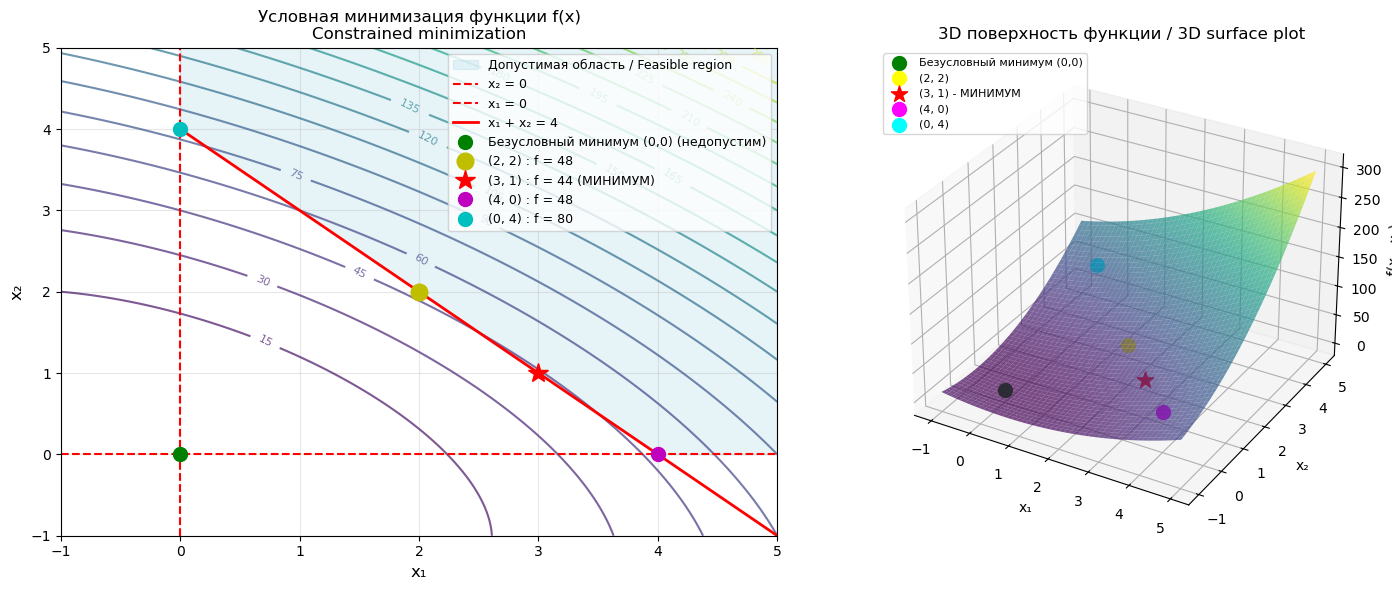


На левом графике показаны:
  • Синяя область - допустимая область (x₁ ≥ 0, x₂ ≥ 0, x₁ + x₂ ≥ 4)
  • Красная звезда - условный минимум в точке (3, 1) со значением f = 44
  • Желтая точка - (2, 2) со значением f = 48
  • Зеленая точка - безусловный минимум (0, 0), но он недопустим

На правом графике показана 3D поверхность функции
Красная звезда на поверхности - найденный условный минимум

✅ Визуализация завершена


In [11]:
# ============================================================================
# ВИЗУАЛИЗАЦИЯ ФУНКЦИИ И ОБЛАСТИ ДОПУСТИМЫХ РЕШЕНИЙ
# VISUALIZATION OF FUNCTION AND FEASIBLE REGION
# ============================================================================

print("=" * 60)
print("ВИЗУАЛИЗАЦИЯ / VISUALIZATION")
print("=" * 60)

# Создаем сетку для контурного графика
x1_vals = np.linspace(-1, 5, 200)
x2_vals = np.linspace(-1, 5, 200)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Вычисляем значения функции
F = 3*X1**2 + 4*X1*X2 + 5*X2**2

# Создаем фигуру с двумя подграфиками
fig = plt.figure(figsize=(15, 6))

# ============================================================================
# Левый график: Контурный график с областью допустимых решений
# ============================================================================
ax1 = fig.add_subplot(1, 2, 1)

# Контурный график
contour = ax1.contour(X1, X2, F, levels=20, cmap='viridis', alpha=0.7)
ax1.clabel(contour, inline=True, fontsize=8, fmt='%d')

# Заливка допустимой области (x1 ≥ 0, x2 ≥ 0, x1 + x2 ≥ 4)
x_fill = np.linspace(0, 5, 100)
y_fill_lower = np.maximum(0, 4 - x_fill)
ax1.fill_between(x_fill, y_fill_lower, 5, where=(x_fill >= 0), 
                  alpha=0.3, color='lightblue', label='Допустимая область / Feasible region')

# Линии ограничений
ax1.axhline(0, color='red', linestyle='--', linewidth=1.5, label='x₂ = 0')
ax1.axvline(0, color='red', linestyle='--', linewidth=1.5, label='x₁ = 0')
ax1.plot(x_fill, 4 - x_fill, 'r-', linewidth=2, label='x₁ + x₂ = 4')

# Точки
ax1.plot(0, 0, 'go', markersize=10, label='Безусловный минимум (0,0) (недопустим)')
ax1.plot(2, 2, 'yo', markersize=12, label='(2, 2) : f = 48')
ax1.plot(3, 1, 'r*', markersize=15, label='(3, 1) : f = 44 (МИНИМУМ)')
ax1.plot(4, 0, 'mo', markersize=10, label='(4, 0) : f = 48')
ax1.plot(0, 4, 'co', markersize=10, label='(0, 4) : f = 80')

ax1.set_xlabel('x₁', fontsize=12)
ax1.set_ylabel('x₂', fontsize=12)
ax1.set_title('Условная минимизация функции f(x)\nConstrained minimization', fontsize=12)
ax1.set_xlim(-1, 5)
ax1.set_ylim(-1, 5)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=9)

# ============================================================================
# Правый график: 3D поверхность
# ============================================================================
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# 3D поверхность
surf = ax2.plot_surface(X1, X2, F, cmap='viridis', alpha=0.7, edgecolor='none')

# Точки на поверхности
z_min_unconstrained = 0
ax2.scatter(0, 0, z_min_unconstrained, color='green', s=100, label='Безусловный минимум (0,0)')

z_2_2 = 48
ax2.scatter(2, 2, z_2_2, color='yellow', s=100, label='(2, 2)')

z_3_1 = 44
ax2.scatter(3, 1, z_3_1, color='red', s=150, label='(3, 1) - МИНИМУМ', marker='*')

z_4_0 = 48
ax2.scatter(4, 0, z_4_0, color='magenta', s=100, label='(4, 0)')

z_0_4 = 80
ax2.scatter(0, 4, z_0_4, color='cyan', s=100, label='(0, 4)')

ax2.set_xlabel('x₁', fontsize=10)
ax2.set_ylabel('x₂', fontsize=10)
ax2.set_zlabel('f(x₁, x₂)', fontsize=10)
ax2.set_title('3D поверхность функции / 3D surface plot', fontsize=12)
ax2.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

print("\nНа левом графике показаны:")
print("  • Синяя область - допустимая область (x₁ ≥ 0, x₂ ≥ 0, x₁ + x₂ ≥ 4)")
print("  • Красная звезда - условный минимум в точке (3, 1) со значением f = 44")
print("  • Желтая точка - (2, 2) со значением f = 48")
print("  • Зеленая точка - безусловный минимум (0, 0), но он недопустим")

print("\nНа правом графике показана 3D поверхность функции")
print("Красная звезда на поверхности - найденный условный минимум")

print("\n✅ Визуализация завершена")